In [1]:
import cudf
import cupy as cp
import xgboost as xgb
import pandas as pd

In [1]:
src_data_path = "/root/data/ppmi/data_ppmi.parquet"
import pandas as pd
df = pd.read_parquet(src_data_path)

In [19]:
df = df[df["Sample_Group"].isin(["Control", "PD"])]

In [20]:
any(item.startswith("ch") for item in df.columns)
df.shape

(431, 776968)

In [21]:
target_var = "Sample_Group"
meta_cols = [col for col in df.columns if not (col.startswith("cg") or col.startswith("ch"))]

In [34]:
Y_pd = df[target_var]
X_pd = df.drop(columns=meta_cols)

Y_pd = Y_pd.map({"Control": 0, "PD": 1})

In [35]:
X = X_pd.to_numpy(dtype="float32")
Y = Y_pd.to_numpy(dtype="float32")

In [36]:
from cuml.linear_model import LogisticRegression

enet_classifier = LogisticRegression(
    penalty='elasticnet',
    C=1.0,
    l1_ratio=0.5,
    solver='qn',
    max_iter=10000
)
enet_classifier.fit(X, Y)

LogisticRegression()

In [37]:
coefficients = enet_classifier.coef_.flatten()

In [38]:
feature_names = X_pd.columns.to_numpy()

In [40]:
selected_mask = np.abs(coefficients) > 1e-6

In [44]:
selected_features = feature_names[selected_mask]
selected_weights = coefficients[selected_mask]

print(f"Total features originally: {len(feature_names)}")
print(f"Features selected by ElasticNet: {len(selected_features)}")

Total features originally: 776947
Features selected by ElasticNet: 427


In [45]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'CpG_Site': selected_features,
    'Coefficient': selected_weights,
    'Absolute_Importance': np.abs(selected_weights)
})

In [46]:
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

print("\n--- Top Selected Features ---")
print(feature_importance_df.head(20))


--- Top Selected Features ---
      CpG_Site  Coefficient  Absolute_Importance
0   cg02630646    -0.276214             0.276214
1   cg25403368     0.274766             0.274766
2   cg14236618    -0.256131             0.256131
3   cg15991630    -0.244650             0.244650
4   cg23868571    -0.232018             0.232018
5   cg24395774     0.231050             0.231050
6   cg21788897    -0.229804             0.229804
7   cg01030629     0.223596             0.223596
8   cg06612594    -0.198064             0.198064
9   cg00814218     0.197040             0.197040
10  cg16970289     0.190566             0.190566
11  cg26284196     0.187517             0.187517
12  cg03058016     0.186211             0.186211
13  cg24717262    -0.184053             0.184053
14  cg08476006     0.178379             0.178379
15  cg10829391    -0.174418             0.174418
16  cg21059158     0.167687             0.167687
17  cg12995006     0.165980             0.165980
18  cg03484420    -0.164968           

In [49]:
%conda install conda-forge::optuna

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - conda-forge::optuna


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    optuna-3.6.1               |     pyhd8ed1ab_0         218 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         218 KB

The following NEW packages will be INSTALLED:

  alembic            pkgs/main/linux-64::alembic-1.18.4-py313h06a4308_0 
  colorlog           pkgs/main/linux-64::colorlog-6.10.1-py313h06a4308_0 
  greenlet           pkgs/main/linux-64::greenlet-3.3.2-py313h7354ed3_0 
  mako               pkgs/main/linux-64::mako-1.3.11-py313h06a4308_0 
  optuna             conda-forge/noarc

In [51]:
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Filter your data to the selected features only
# X_pd and Y_pd are your cleaned Pandas objects from the previous step
X_selected = X_pd[selected_features].to_numpy(dtype=np.float32)
y_numpy = Y_pd.to_numpy(dtype=np.float32)

# 2. Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_selected, y_numpy, test_size=0.2, random_state=42
)

# 3. Define the Objective Function for Optuna
def objective(trial):
    # Define the search space
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        # GPU Settings
        "tree_method": "hist",
        "device": "cuda",
        # Hyperparameters to tune
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, step=0.01),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

    # Add a pruning callback to stop unpromising trials early
    model = xgb.XGBClassifier(**param, n_estimators=1000, early_stopping_rounds=50)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    preds = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, preds)
    return auc

# 4. Run the Study
print("Starting Hyperparameter Tuning on GPU...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) # Increase n_trials for better results

print("\n--- Optimization Finished ---")
print(f"Best AUC: {study.best_value:.4f}")
print("Best Params:", study.best_params)

# 5. Train Final Model with Best Parameters
best_params = study.best_params
best_params["tree_method"] = "hist"
best_params["device"] = "cuda"

final_model = xgb.XGBClassifier(**best_params, n_estimators=500)
final_model.fit(X_train, y_train)

[I 2026-05-09 10:12:47,605] A new study created in memory with name: no-name-844e55c2-8934-4f50-bd50-4be4d57555a2


Starting Hyperparameter Tuning on GPU...


[I 2026-05-09 10:12:47,949] Trial 0 finished with value: 0.5626865671641791 and parameters: {'lambda': 0.002170197540887957, 'alpha': 0.2859963733724501, 'learning_rate': 0.02, 'max_depth': 3, 'subsample': 0.5616156365143643, 'colsample_bytree': 0.6304934826578232, 'min_child_weight': 9}. Best is trial 0 with value: 0.5626865671641791.
[I 2026-05-09 10:12:48,197] Trial 1 finished with value: 0.7485074626865671 and parameters: {'lambda': 4.96471823929957, 'alpha': 0.08701580076605485, 'learning_rate': 0.12, 'max_depth': 7, 'subsample': 0.5038784696966356, 'colsample_bytree': 0.9520391517833652, 'min_child_weight': 9}. Best is trial 1 with value: 0.7485074626865671.
[I 2026-05-09 10:12:48,367] Trial 2 finished with value: 0.714179104477612 and parameters: {'lambda': 0.15123640285943812, 'alpha': 0.005278008643820706, 'learning_rate': 0.16, 'max_depth': 4, 'subsample': 0.951449145133034, 'colsample_bytree': 0.8531536773349624, 'min_child_weight': 3}. Best is trial 1 with value: 0.74850746


--- Optimization Finished ---
Best AUC: 0.8522
Best Params: {'lambda': 1.2516163994903533, 'alpha': 0.4110226412435196, 'learning_rate': 0.15000000000000002, 'max_depth': 9, 'subsample': 0.5074517534679553, 'colsample_bytree': 0.6800129733058065, 'min_child_weight': 2}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6800129733058065
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impor

In [58]:
%conda install conda-forge::seaborn

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - conda-forge::seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    patsy-1.0.2                |  py313h06a4308_0         518 KB
    seaborn-0.13.2             |       hd8ed1ab_3           7 KB  conda-forge
    seaborn-base-0.13.2        |     pyhd8ed1ab_3         223 KB  conda-forge
    statsmodels-0.14.6         |  py313h47b2149_0        11.6 MB
    ------------------------------------------------------------
                                           Total:        12.3 MB

The following NEW packages will be INSTALLED:

  patsy              pkgs/main/linux-64::patsy-1.0.2-py313h06a4308_0 
  seaborn            conda-forge/noarch::seaborn-

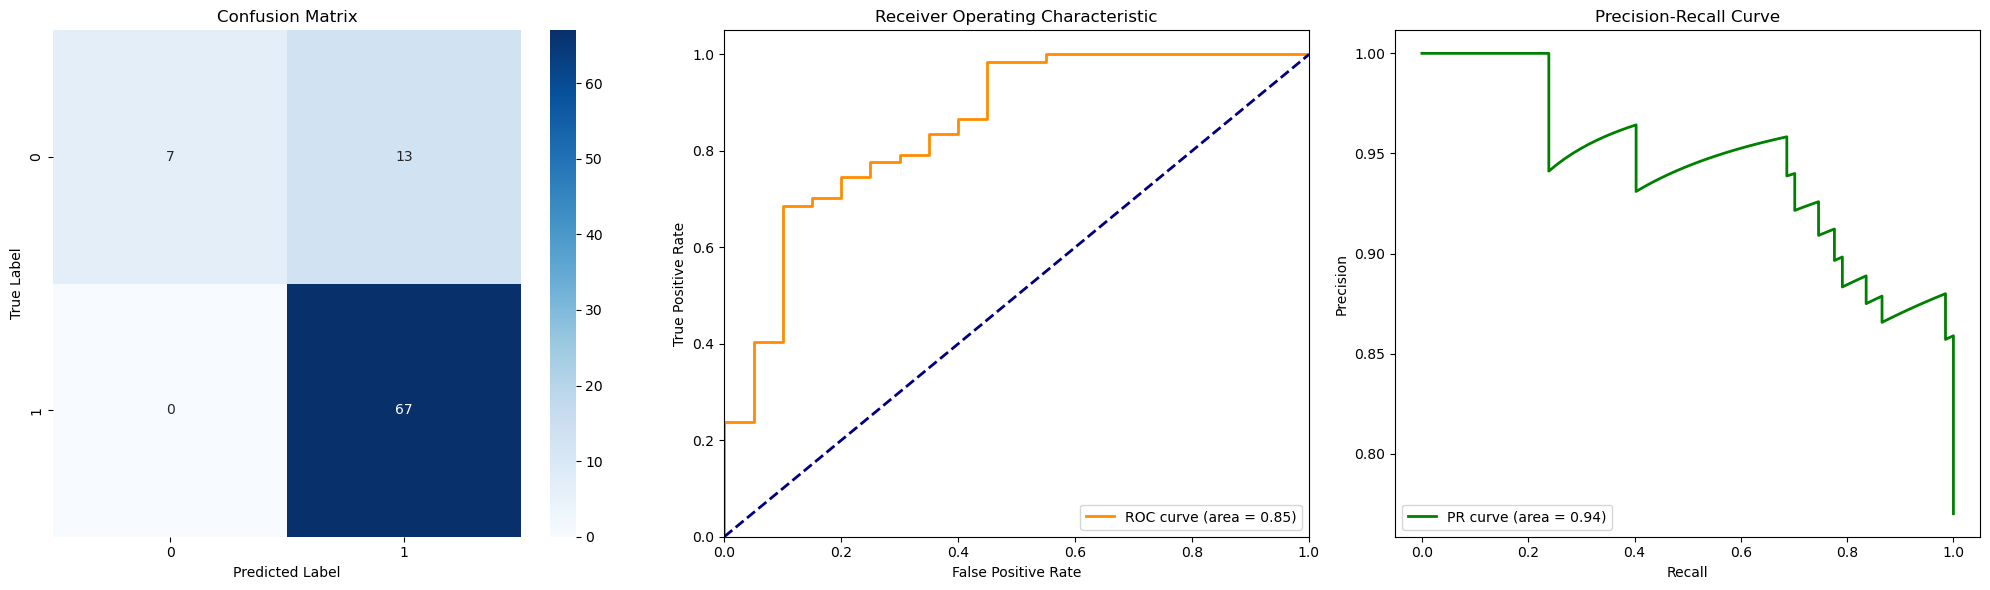

ROC-AUC: 0.8507
PR-AUC: 0.9436


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

# 1. Get Predictions
# We need probabilities for the curves and hard labels for the confusion matrix
y_probs = final_model.predict_proba(X_valid)[:, 1]
y_preds = final_model.predict(X_valid)

# 2. Setup Plotting Area
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_valid, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# --- Plot 2: ROC-AUC Curve ---
fpr, tpr, _ = roc_curve(y_valid, y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

# --- Plot 3: PR-AUC Curve ---
precision, recall, _ = precision_recall_curve(y_valid, y_probs)
pr_auc = average_precision_score(y_valid, y_probs)
ax[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
ax[2].set_xlabel('Recall')
ax[2].set_ylabel('Precision')
ax[2].set_title('Precision-Recall Curve')
ax[2].legend(loc="lower left")

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

Running 10-Fold CV...


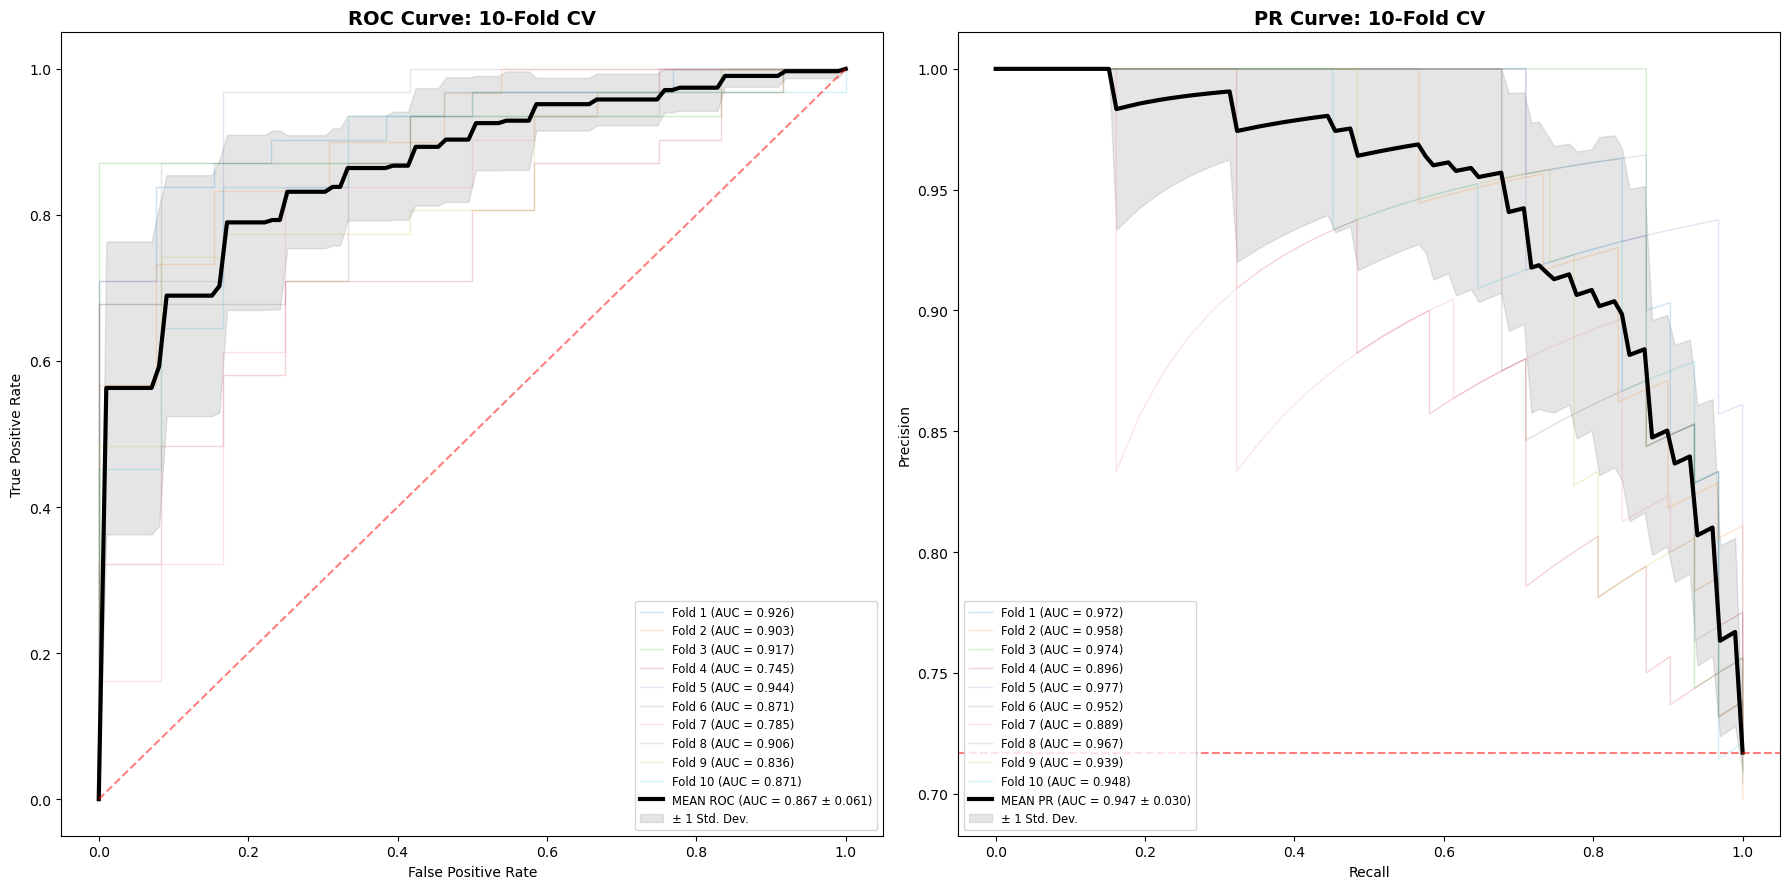

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import xgboost as xgb

# 1. Setup 10-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Buffers for averaging
tprs = []
aucs_roc = []
mean_fpr = np.linspace(0, 1, 100)

precisions = []
aucs_pr = []
mean_recall = np.linspace(0, 1, 100)

# Setup plotting area
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(18, 9))

# Configuration for GPU
xgb_params = best_params.copy()
xgb_params.update({"tree_method": "hist", "device": "cuda"})

print("Running 10-Fold CV...")

# 2. Iterate through folds
for i, (train_idx, val_idx) in enumerate(cv.split(X_selected, y_numpy)):
    X_train_cv, X_val_cv = X_selected[train_idx], X_selected[val_idx]
    y_train_cv, y_val_cv = y_numpy[train_idx], y_numpy[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params, n_estimators=500)
    model.fit(X_train_cv, y_train_cv, verbose=False)
    y_probs = model.predict_proba(X_val_cv)[:, 1]
    
    # --- ROC Fold ---
    fpr, tpr, _ = roc_curve(y_val_cv, y_probs)
    fold_roc_auc = auc(fpr, tpr)
    aucs_roc.append(fold_roc_auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    
    # Plot individual fold with label for legend
    ax_roc.plot(fpr, tpr, alpha=0.2, lw=1, label=f'Fold {i+1} (AUC = {fold_roc_auc:.3f})')
    
    # --- PR Fold ---
    precision, recall, _ = precision_recall_curve(y_val_cv, y_probs)
    fold_pr_auc = average_precision_score(y_val_cv, y_probs)
    aucs_pr.append(fold_pr_auc)
    
    # Interpolate for PR
    rev_recall, rev_precision = recall[::-1], precision[::-1]
    precisions.append(np.interp(mean_recall, rev_recall, rev_precision))
    
    # Plot individual fold with label for legend
    ax_pr.plot(recall, precision, alpha=0.2, lw=1, label=f'Fold {i+1} (AUC = {fold_pr_auc:.3f})')

# 3. Calculate and Plot Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)
mean_auc_roc = auc(mean_fpr, mean_tpr)
std_auc_roc = np.std(aucs_roc)

ax_roc.plot(mean_fpr, mean_tpr, color='black', lw=3, 
            label=f'MEAN ROC (AUC = {mean_auc_roc:.3f} ± {std_auc_roc:.3f})')

# Shade ROC Variance
ax_roc.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1), 
                     color='grey', alpha=0.2, label='± 1 Std. Dev.')

# 4. Calculate and Plot Mean PR
mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
mean_auc_pr = np.mean(aucs_pr)
std_auc_pr = np.std(aucs_pr)

ax_pr.plot(mean_recall, mean_precision, color='black', lw=3,
           label=f'MEAN PR (AUC = {mean_auc_pr:.3f} ± {std_auc_pr:.3f})')

# Shade PR Variance
ax_pr.fill_between(mean_recall, np.maximum(mean_precision - std_precision, 0), np.minimum(mean_precision + std_precision, 1), 
                    color='grey', alpha=0.2, label='± 1 Std. Dev.')

# 5. Final Formatting
# ROC axis setup
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.5)
ax_roc.set_title('ROC Curve: 10-Fold CV', fontsize=14, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
# Use a smaller font for the legend to fit all 10 folds
ax_roc.legend(loc='lower right', fontsize='small', ncol=1)

# PR axis setup
baseline = np.sum(y_numpy) / len(y_numpy)
ax_pr.axhline(baseline, linestyle='--', color='red', alpha=0.5)
ax_pr.set_title('PR Curve: 10-Fold CV', fontsize=14, fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left', fontsize='small', ncol=1)

plt.tight_layout()
plt.savefig('cv_detailed_results.png', dpi=300)
plt.show()

In [64]:
%conda install main::shap

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - main
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - main::shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    shap-0.51.0                |  py313h73fd927_1         4.2 MB  main
    slicer-0.0.8               |  py313h77c3f3f_2          44 KB
    ------------------------------------------------------------
                                           Total:         4.3 MB

The following NEW packages will be INSTALLED:

  shap               main/linux-64::shap-0.51.0-py313h73fd927_1 
  slicer             pkgs/main/linux-64::slicer-0.0.8-py313h77c3f3f_2 



shap-0.51.0          | 4.2 MB    |                                       |   0% 
slicer-0.0.8         | 44 KB     |                                

In [65]:
import shap
import numpy as np
import pandas as pd

# 1. Initialize the Explainer
# XGBoost models have a native integration that SHAP leverages for GPU speed
explainer = shap.TreeExplainer(final_model)

# 2. Calculate SHAP values
# We use the selected features dataset. 
# For XGBoost, it's often best to pass the data as a DataFrame to keep feature names
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
shap_values = explainer.shap_values(X_selected_df)

# Note: For binary classification, shap_values is often a single array.
# If your model output is a list (for multiclass), you would use shap_values[1] for the positive class.

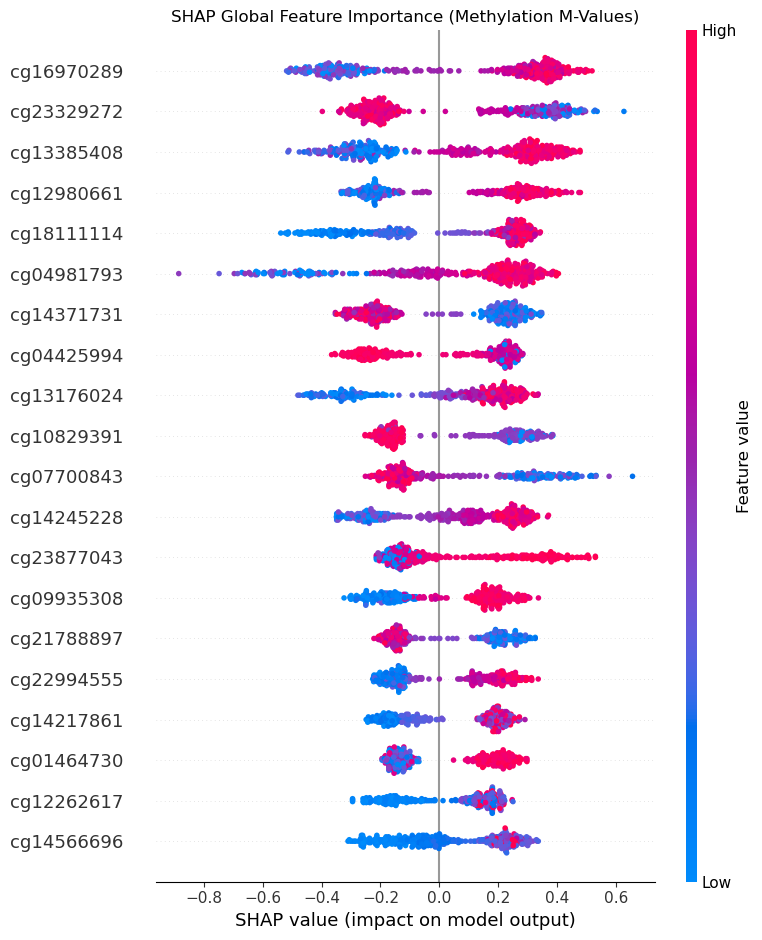

In [66]:
# 3. Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_selected_df, show=False)
plt.title("SHAP Global Feature Importance (Methylation M-Values)")
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300)
plt.show()

In [67]:
%conda install bioconda::gseapy

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - bioconda
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - bioconda::gseapy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    gseapy-1.2.1               |  py313h551aa79_0         639 KB  bioconda
    pyopengl-3.1.10            |  py313h06a4308_0         2.3 MB
    ------------------------------------------------------------
                                           Total:         3.0 MB

The following NEW packages will be INSTALLED:

  gseapy             bioconda/linux-64::gseapy-1.2.1-py313h551aa79_0 
  pyopengl           pkgs/main/linux-64::pyopengl-3.1.10-py313h06a4308_0 



pyopengl-3.1.10      | 2.3 MB    |                                       |   0% 
gseapy-1.2.1         | 639 KB    |          

In [83]:
mani = pd.read_csv("/root/data/ppmi/infinium-epic-v1.csv", sep=",", skiprows=7, encoding='utf-8')

/tmp/ipykernel_6426/2896854533.py:1: DtypeWarning: Columns (2,4,42,47) have mixed types. Specify dtype option on import or set low_memory=False.
  mani = pd.read_csv("/root/data/ppmi/infinium-epic-v1.csv", sep=",", skiprows=7, encoding='utf-8')


In [ ]:
mani.columns
# usecols=['Name', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group'],

Index(['IlmnID', 'Name', 'AddressA_ID', 'AlleleA_ProbeSeq', 'AddressB_ID',
       'AlleleB_ProbeSeq', 'Infinium_Design_Type', 'Next_Base',
       'Color_Channel', 'Forward_Sequence', 'Genome_Build', 'CHR', 'MAPINFO',
       'SourceSeq', 'Strand', 'UCSC_RefGene_Name', 'UCSC_RefGene_Accession',
       'UCSC_RefGene_Group', 'UCSC_CpG_Islands_Name',
       'Relation_to_UCSC_CpG_Island', 'Phantom4_Enhancers',
       'Phantom5_Enhancers', 'DMR', '450k_Enhancer', 'HMM_Island',
       'Regulatory_Feature_Name', 'Regulatory_Feature_Group',
       'GencodeBasicV12_NAME', 'GencodeBasicV12_Accession',
       'GencodeBasicV12_Group', 'GencodeCompV12_NAME',
       'GencodeCompV12_Accession', 'GencodeCompV12_Group',
       'DNase_Hypersensitivity_NAME', 'DNase_Hypersensitivity_Evidence_Count',
       'OpenChromatin_NAME', 'OpenChromatin_Evidence_Count', 'TFBS_NAME',
       'TFBS_Evidence_Count', 'Methyl27_Loci', 'Methyl450_Loci',
       'Chromosome_36', 'Coordinate_36', 'SNP_ID', 'SNP_DISTANCE',
    

Loading annotation manifest...
Extracting unique gene targets...
Mapped 427 CpG sites to 294 unique genes.
Running Enrichr API (requires internet connection)...

Found 28 significant pathways!


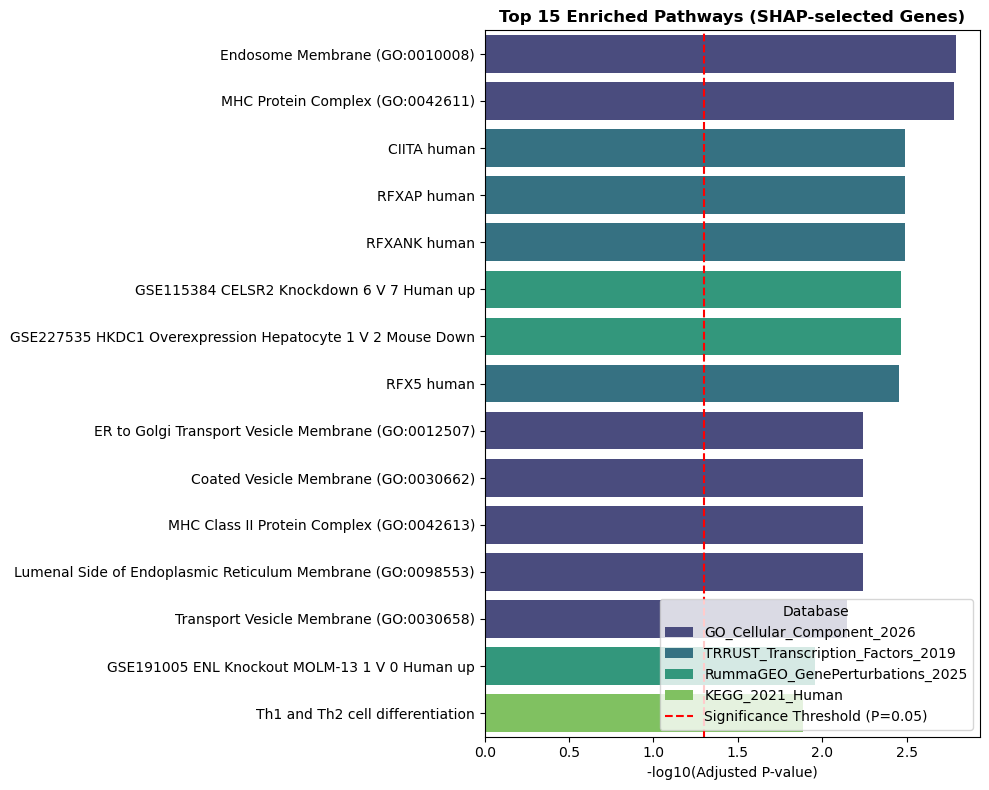

In [ ]:
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Extract Top Features from SHAP ---
# Calculate the mean absolute SHAP value for every feature across all samples
shap_importances = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'CpG': X_selected_df.columns,
    'SHAP_Importance': shap_importances
}).sort_values('SHAP_Importance', ascending=False)

top_cpgs = shap_df.head(500)

# --- 2. Load the Illumina Manifest ---
# You need the official Illumina manifest file (EPIC or 450k) downloaded locally.
# If you don't have it, you can often download the CSV version from Illumina's website.
manifest_path = '/root/data/ppmi/infinium-epic-v1.csv' 

print("Loading annotation manifest...")
# We only load the columns we care about to save memory
manifest = pd.read_csv(
    manifest_path, 
    skiprows=7,
    usecols=['Name', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group'],
    dtype=str,
    encoding='utf-8'
)

# Merge our top SHAP features with the genomic annotations
mapped_cpgs = pd.merge(top_cpgs, manifest, left_on='CpG', right_on='Name', how='left')

# --- 3. Clean Up Illumina's Gene Names ---
# Illumina manifests often list multiple genes per probe separated by semicolons
# (e.g., "GENE1;GENE1;GENE2"). We need to split these and get a unique list.
print("Extracting unique gene targets...")

# Drop probes that don't map to a known gene
genes_raw = mapped_cpgs['UCSC_RefGene_Name'].dropna()

# Split semicolons, flatten the list, and remove duplicates
gene_list = genes_raw.str.split(';').explode().unique().tolist()

# Remove any empty strings just in case
gene_list = [g for g in gene_list if g.strip() != '']

print(f"Mapped {len(top_cpgs)} CpG sites to {len(gene_list)} unique genes.")

# --- 4. Functional Enrichment Analysis using GSEApy ---
print("Running Enrichr API (requires internet connection)...")

# We will query both Gene Ontology (Biological Process) and KEGG Pathways
# You can see all available databases by running: gp.get_library_name()
databases = ['GO_Biological_Process_2026', 'KEGG_2021_Human', 
'ENCODE_Histone_Modifications_2015',
'ENCODE_TF_ChIP-seq_2015',
'Elsevier_Pathway_Collection',
'GO_Cellular_Component_2026',
'GO_Molecular_Function_2026',
'Ligand_Perturbations_from_GEO_down',
'Ligand_Perturbations_from_GEO_up',
'Microbe_Perturbations_from_GEO_down',
'Microbe_Perturbations_from_GEO_up',
'Panther_2016',
'ProteomicsDB_2020',
'Reactome_Pathways_2024',
'RummaGEO_GenePerturbations_2025',
'SynGO_2024',
'TRANSFAC_and_JASPAR_PWMs',
'TRRUST_Transcription_Factors_2019',
'The_Kinase_Library_2024',
'WikiPathways_2024_Human']

enrichment_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='human',
    outdir=None # Set to a path if you want to save the raw tables automatically
)

# --- 5. Visualize the Results ---
# Get the results table
res_df = enrichment_results.results

# Filter for statistically significant pathways (Adjusted P-value < 0.05)
significant_pathways = res_df[res_df['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')

if significant_pathways.empty:
    print("\nNo pathways reached statistical significance (Adj. P < 0.05).")
else:
    print(f"\nFound {len(significant_pathways)} significant pathways!")
    
    # Plot the top 15 pathways
    plt.figure(figsize=(10, 8))
    
    # We use -log10(P-value) for the x-axis (longer bar = more significant)
    top_plot = significant_pathways.head(15).copy()
    top_plot['-log10(Adj. P)'] = -np.log10(top_plot['Adjusted P-value'])
    
    sns.barplot(
        data=top_plot,
        x='-log10(Adj. P)',
        y='Term',
        hue='Gene_set',
        dodge=False,
        palette='viridis'
    )
    
    plt.title('Top 15 Enriched Pathways (SHAP-selected Genes)', fontweight='bold')
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('')
    plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (P=0.05)')
    plt.legend(title='Database', loc='lower right')
    plt.tight_layout()
    plt.savefig('shap_pathway_enrichment.png', dpi=300)
    plt.show()

# Optional: Save the mapping and enrichment results to CSV for your records
mapped_cpgs.to_csv('top_cpgs_annotated.csv', index=False)
significant_pathways.to_csv('enrichment_results.csv', index=False)

Calculating SHAP directions...
Aggregating metrics to the gene level...
Calculating pathway-level SHAP metrics...
Generating visualization...


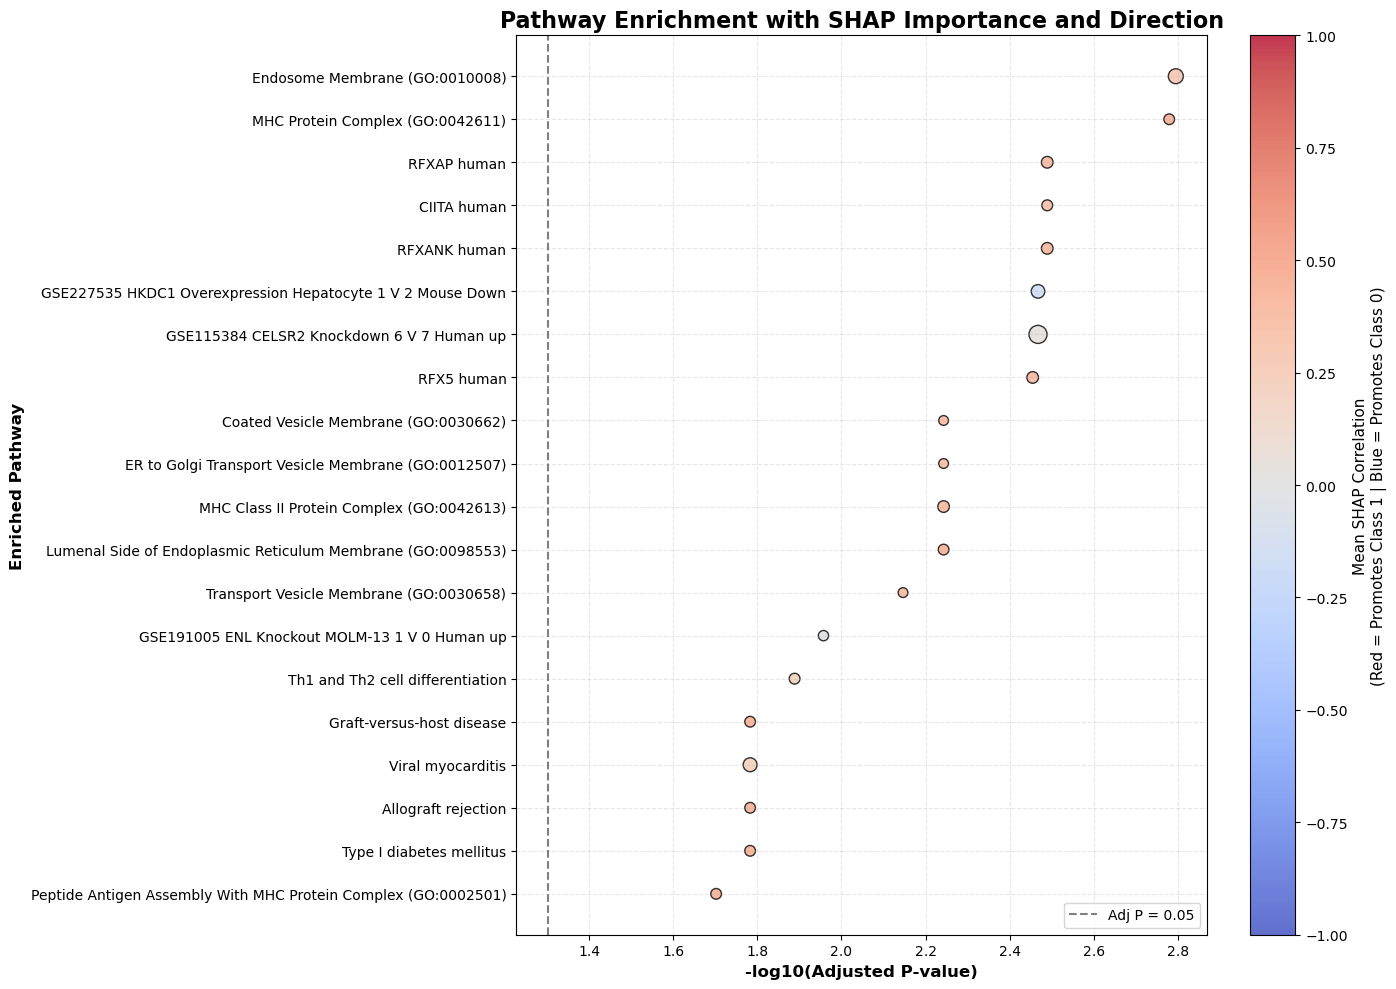

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import ast # To parse the overlap column safely

# --- 1. Calculate SHAP Direction & Importance per CpG ---
print("Calculating SHAP directions...")

cpg_stats = []
for i, cpg in enumerate(X_selected_df.columns):
    # Importance is the mean absolute SHAP value
    importance = np.abs(shap_values[:, i]).mean()
    
    # Direction is the correlation between the M-value and the SHAP value
    # If standard deviation is 0, correlation is 0
    feature_vals = X_selected_df[cpg].values
    shap_vals = shap_values[:, i]
    
    if np.std(feature_vals) == 0 or np.std(shap_vals) == 0:
        correlation = 0
    else:
        correlation, _ = pearsonr(feature_vals, shap_vals)
        
    cpg_stats.append({
        'CpG': cpg,
        'SHAP_Importance': importance,
        'SHAP_Correlation': correlation
    })

cpg_df = pd.DataFrame(cpg_stats)

# --- 2. Map CpGs to Genes and Aggregate ---
print("Aggregating metrics to the gene level...")

# Merge with the manifest (assuming you still have 'mapped_cpgs' from the previous step)
mapped_stats = pd.merge(cpg_df, mapped_cpgs[['CpG', 'UCSC_RefGene_Name']], on='CpG', how='inner')

# Clean up genes (split semicolons)
mapped_stats = mapped_stats.dropna(subset=['UCSC_RefGene_Name'])
mapped_stats['UCSC_RefGene_Name'] = mapped_stats['UCSC_RefGene_Name'].str.split(';')
mapped_stats = mapped_stats.explode('UCSC_RefGene_Name')
mapped_stats['Gene'] = mapped_stats['UCSC_RefGene_Name'].str.strip()

# Aggregate SHAP Importance (Sum) and Direction (Mean) per Gene
gene_stats = mapped_stats.groupby('Gene').agg({
    'SHAP_Importance': 'sum',
    'SHAP_Correlation': 'mean' 
}).reset_index()

# Create a dictionary for rapid lookup
gene_importance_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Importance']))
gene_direction_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Correlation']))


# --- 3. Process Enrichr Results ---
print("Calculating pathway-level SHAP metrics...")

# Assuming `res_df` is your output dataframe from gp.enrichr().results
# Filter for significant pathways
sig_pathways = res_df[res_df['Adjusted P-value'] < 0.05].copy()

if sig_pathways.empty:
    raise ValueError("No significant pathways found to plot. Try relaxing the P-value or use Preranked GSEA.")

# Add custom metrics to the pathways
pathway_data = []

for index, row in sig_pathways.iterrows():
    # Enrichr returns overlapping genes as a string separated by semicolons
    overlap_genes = row['Genes'].split(';') 
    
    # Calculate Pathway SHAP Importance (Mean importance of the overlapping genes)
    p_importances = [gene_importance_dict.get(g, 0) for g in overlap_genes]
    pathway_importance = np.mean(p_importances) if p_importances else 0
    
    # Calculate Pathway Direction (Mean correlation of the overlapping genes)
    p_directions = [gene_direction_dict.get(g, 0) for g in overlap_genes]
    pathway_direction = np.mean(p_directions) if p_directions else 0
    
    pathway_data.append({
        'Term': row['Term'],
        'Database': row['Gene_set'],
        '-log10(Adj.P)': -np.log10(row['Adjusted P-value']),
        'Pathway_Importance': pathway_importance,
        'Pathway_Direction': pathway_direction,
        'Gene_Count': len(overlap_genes)
    })

plot_df = pd.DataFrame(pathway_data)

# Sort by significance and take the top 20 to avoid overcrowding the plot
plot_df = plot_df.sort_values('-log10(Adj.P)', ascending=False).head(20)


# --- 4. Generate the Advanced Bubble Plot ---
print("Generating visualization...")
plt.figure(figsize=(14, 10))

# Create the scatter plot
scatter = plt.scatter(
    x=plot_df['-log10(Adj.P)'], 
    y=plot_df['Term'],
    s=plot_df['Pathway_Importance'] * 1000, # Scale up for visibility
    c=plot_df['Pathway_Direction'], 
    cmap='coolwarm',       # Blue (negative) to Red (positive)
    edgecolors='black', 
    alpha=0.8,
    vmin=-1, vmax=1      # Fix scale bounds for correlation
)

# Formatting
plt.title('Pathway Enrichment with SHAP Importance and Direction', fontsize=16, fontweight='bold')
plt.xlabel('-log10(Adjusted P-value)', fontsize=12, fontweight='bold')
plt.ylabel('Enriched Pathway', fontsize=12, fontweight='bold')

# Colorbar for Direction
cbar = plt.colorbar(scatter)
cbar.set_label('Mean SHAP Correlation\n(Red = Promotes Class 1 | Blue = Promotes Class 0)', fontsize=11)

# Add a significance threshold line
plt.axvline(-np.log10(0.05), color='gray', linestyle='--', label='Adj P = 0.05')
plt.legend(loc='lower right')

# Clean up the Y-axis labels
plt.gca().invert_yaxis() # Put most significant at the top
plt.grid(True, axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_pathway_bubble_plot.png', dpi=300)
plt.show()

In [100]:
significant_pathways.sort_values('Adjusted P-value', inplace=True)
significant_pathways

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
3705,GO_Cellular_Component_2026,Endosome Membrane (GO:0010008),20/439,0.000009,0.001603,0,0,3.359929,39.164868,HLA-DRB5;NOTCH1;TMEM63B;NCF4;HLA-A;ANTXR2;ABCB...
3706,GO_Cellular_Component_2026,MHC Protein Complex (GO:0042611),5/23,0.000018,0.001662,0,0,18.923491,206.778672,HLA-DRB5;HLA-A;HLA-DRB1;HLA-DPA1;HLA-DQB1
11122,TRRUST_Transcription_Factors_2019,CIITA human,5/31,0.000082,0.003241,0,0,13.095555,123.151445,HLA-DRB5;HLA-A;SLC26A3;HLA-DRB1;HLA-DQB1
11121,TRRUST_Transcription_Factors_2019,RFXAP human,4/15,0.000055,0.003241,0,0,24.695925,242.243280,HLA-DRB5;HLA-DRB1;HLA-DPA1;HLA-DQB1
11120,TRRUST_Transcription_Factors_2019,RFXANK human,4/15,0.000055,0.003241,0,0,24.695925,242.243280,HLA-DRB5;HLA-DRB1;HLA-DPA1;HLA-DQB1
7064,RummaGEO_GenePerturbations_2025,GSE115384 CELSR2 Knockdown 6 V 7 Human up,48/1606,0.000002,0.003408,0,0,2.272833,30.027397,USP6NL;HDAC4;TNFAIP8;ROCK2;MGST3;STK39;ANTXR2;...
7063,RummaGEO_GenePerturbations_2025,GSE227535 HKDC1 Overexpression Hepatocyte 1 V ...,21/418,0.000001,0.003408,0,0,3.741329,51.305828,ITIH5;ARHGEF10;TNFAIP8;SLC24A3;ROCK2;GALNT2;PD...
11123,TRRUST_Transcription_Factors_2019,RFX5 human,4/18,0.000119,0.003510,0,0,19.400985,175.318742,HLA-DRB5;HLA-DRB1;HLA-DPA1;HLA-DQB1
3710,GO_Cellular_Component_2026,ER to Golgi Transport Vesicle Membrane (GO:001...,6/57,0.000185,0.005716,0,0,8.029003,68.993506,HLA-DRB5;SEC16A;HLA-A;HLA-DRB1;HLA-DPA1;HLA-DQB1
3709,GO_Cellular_Component_2026,Coated Vesicle Membrane (GO:0030662),6/57,0.000185,0.005716,0,0,8.029003,68.993506,HLA-DRB5;SEC16A;HLA-A;HLA-DRB1;HLA-DPA1;HLA-DQB1


In [ ]:
import pandas as pd

# 1. Load your selected features (assuming it's a list or numpy array from earlier)
# selected_features = ... (Your 431 CpG names)
selected_set = set(selected_features)

# 2. Load the 450k Manifest
print("Loading 450k Manifest...")
# We use skiprows=7 because Illumina CSVs usually have 7 lines of header info before the data table
manifest_450k_path = '/root/data/ppmi/450k.csv'
manifest_450k = pd.read_csv(manifest_450k_path, skiprows=7, usecols=['IlmnID'], dtype=str)

# 3. Create a set of all 450k probes
probes_450k = set(manifest_450k['IlmnID'].dropna())

# 4. Perform Set Operations
# Intersection: Probes in BOTH your selected features AND the 450k array
shared_cpgs = selected_set.intersection(probes_450k)

# Difference: Probes in your selected features but NOT in the 450k array (Unique to EPIC)
epic_only_cpgs = selected_set.difference(probes_450k)

print(f"Total features selected by model: {len(selected_set)}")
print(f"Features present in both EPIC and 450k arrays: {len(shared_cpgs)}")
print(f"Features unique to the EPIC array: {len(epic_only_cpgs)}")

# 5. Optional: Add this information back to your original SHAP dataframe for your records
if 'cpg_df' in locals():
    cpg_df['In_450k_Array'] = cpg_df['CpG'].apply(lambda x: x in shared_cpgs)
    print("\nUpdated SHAP Dataframe:")
    print(cpg_df[['CpG', 'SHAP_Importance', 'In_450k_Array']].head())